## Assignment 2 - Deep Learning for Image Classification
**Student ID:** 48658057  
**Name:** Mohammad Rakin Rayan

---

### Task **1.1** - Data Exploration

### Importing Necessary Libraries

In [ ]:
import pandas as pd
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt  
import cv2
from torchvision import  models
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 
import random



Showing one image per class for: Train
Set: Train, Class: paper, Shape: (300, 300, 3)


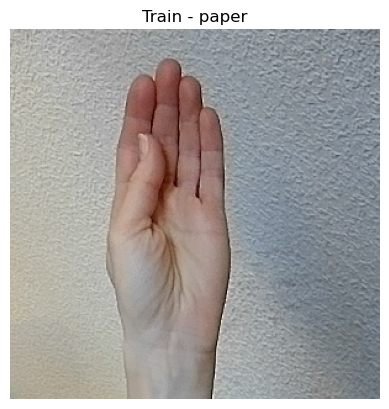

Set: Train, Class: rock, Shape: (300, 300, 3)


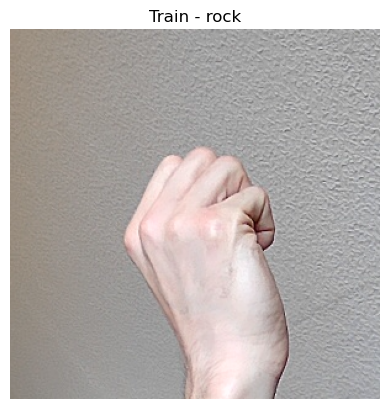

Set: Train, Class: scissors, Shape: (300, 300, 3)


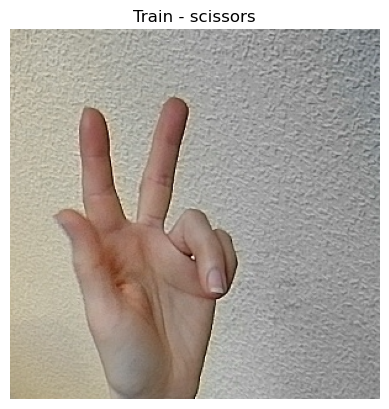


Showing one image per class for: DevTest
Set: DevTest, Class: rock, Shape: (300, 300, 3)


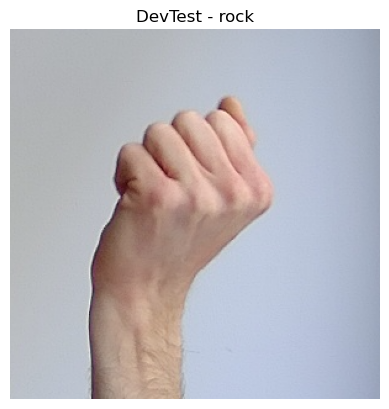

Set: DevTest, Class: scissors, Shape: (300, 300, 3)


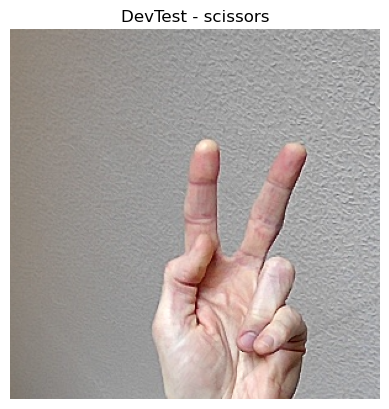

Set: DevTest, Class: paper, Shape: (300, 300, 3)


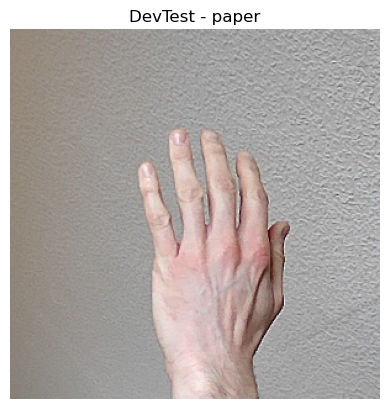


Showing one image per class for: Test
Set: Test, Class: paper, Shape: (300, 300, 3)


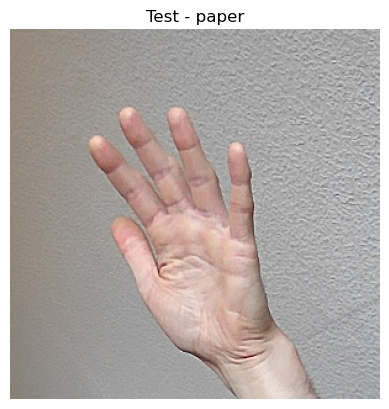

Set: Test, Class: rock, Shape: (300, 300, 3)


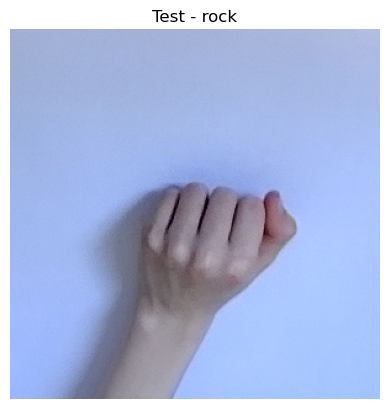

Set: Test, Class: scissors, Shape: (300, 300, 3)


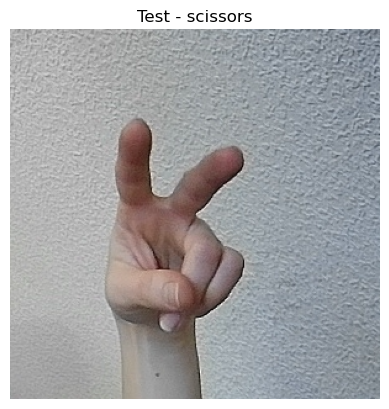


Image counts for Train:
label
paper       544
rock        544
scissors    541
Name: count, dtype: int64

Image counts for DevTest:
label
rock        181
paper       181
scissors    180
Name: count, dtype: int64

Image counts for Test:
label
paper       182
rock        182
scissors    182
Name: count, dtype: int64


In [ ]:
#Task 1.1
# Base directory containing all folders and CSVs
base_dir = r"C:\Users\rekit\OneDrive\Desktop\Semester 4\Artificial Intelligence For Text And Vision (3420)\assignment-2-RakinRayan"

# Load CSV files
train_df = pd.read_csv(os.path.join(base_dir, "train.csv"))
devtest_df = pd.read_csv(os.path.join(base_dir, "devtest.csv"))
test_df = pd.read_csv(os.path.join(base_dir, "test.csv"))

# Function to show one image per class from a set
def show_one_image_per_class(df, set_name):
    print(f"\nShowing one image per class for: {set_name}")
    shown = set()
    
    for _, row in df.iterrows():
        label = row['label']
        filepath = row['path']
        full_path = os.path.join(base_dir, filepath)
        
        if label not in shown and os.path.exists(full_path):
            img = Image.open(full_path)
            img_np = np.array(img)
            
            print(f"Set: {set_name}, Class: {label}, Shape: {img_np.shape}")
            plt.imshow(img_np)
            plt.title(f"{set_name} - {label}")
            plt.axis('off')
            plt.show()
            
            shown.add(label)

        if len(shown) == 3:
            break

# Function to count number of images per class
def count_images_per_class(df, set_name):
    counts = df['label'].value_counts()
    print(f"\nImage counts for {set_name}:")
    print(counts)

# Show images and counts for all splits
show_one_image_per_class(train_df, "Train")
show_one_image_per_class(devtest_df, "DevTest")
show_one_image_per_class(test_df, "Test")

count_images_per_class(train_df, "Train")
count_images_per_class(devtest_df, "DevTest")
count_images_per_class(test_df, "Test")


### **Task 1.2** Data Preparation

In [ ]:
#Task 1.2
# Transform: Resize to 100x100 and rescale pixel values to [0, 1]
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()  # Converts to tensor and rescales pixel values to [0.0, 1.0]
])

# Label-to-index mapping
label_to_idx = {'rock': 0, 'paper': 1, 'scissors': 2}

# Custom Dataset

class RockPaperScissorsDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.root_dir, row['path'])
        image = Image.open(img_path).convert('RGB')
        label = label_to_idx[row['label']]

        if self.transform:
            image = self.transform(image)
        return image, label

# CSV paths
train_csv = os.path.join(base_dir, 'train.csv')
devtest_csv = os.path.join(base_dir, 'devtest.csv')
test_csv = os.path.join(base_dir, 'test.csv')

# Dataset instances
train_dataset = RockPaperScissorsDataset(train_csv, base_dir, transform)
devtest_dataset = RockPaperScissorsDataset(devtest_csv, base_dir, transform)
test_dataset = RockPaperScissorsDataset(test_csv, base_dir, transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
devtest_loader = DataLoader(devtest_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### **Task 2.1** Image Classification Using a Custom Convolutional Neural Network (ConvNet) with PyTorch


#### Setting the device

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Defining the Model

In [ ]:
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),  # [B, 16, 100, 100]
    nn.ReLU(),
    nn.MaxPool2d(2),                             # [B, 16, 50, 50]

    nn.Conv2d(16, 32, kernel_size=3, padding=1), # [B, 32, 50, 50]
    nn.ReLU(),
    nn.MaxPool2d(2),                             # [B, 32, 25, 25]

    nn.Flatten(),                                # [B, 32*25*25]
    nn.Linear(32 * 25 * 25, 128),
    nn.ReLU(),
    nn.Linear(128, 3)                            # Output layer for 3 classes
).to(device)

### Model Training Setup and Accuracy Evaluation

In [ ]:


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 6

train_acc_history = []
dev_acc_history = []

def compute_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

### Model Training Loop with Accuracy Tracking per Epoch

In [53]:
for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    train_acc = compute_accuracy(model, train_loader)
    dev_acc = compute_accuracy(model, devtest_loader)
    train_acc_history.append(train_acc)
    dev_acc_history.append(dev_acc)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Dev Acc = {dev_acc:.4f}")

Epoch 1: Train Acc = 0.5132, Dev Acc = 0.4889
Epoch 2: Train Acc = 0.7354, Dev Acc = 0.7048
Epoch 3: Train Acc = 0.7078, Dev Acc = 0.6790
Epoch 4: Train Acc = 0.8502, Dev Acc = 0.8118
Epoch 5: Train Acc = 0.8778, Dev Acc = 0.8284
Epoch 6: Train Acc = 0.9196, Dev Acc = 0.8764


### Plotting Training and Dev Accuracy Curves Across Epochs

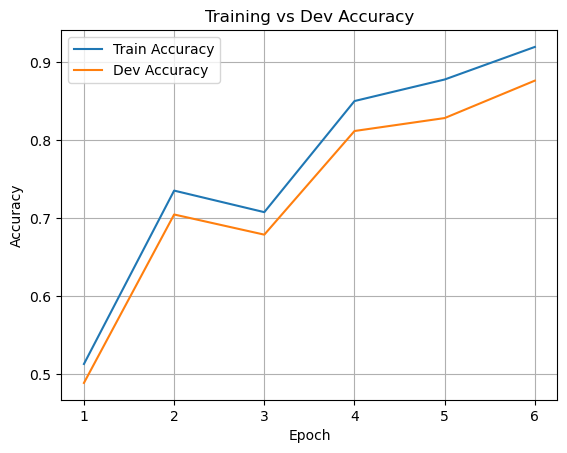

In [ ]:
plt.plot(range(1, num_epochs + 1), train_acc_history, label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), dev_acc_history, label='Dev Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Dev Accuracy')
plt.legend()
plt.grid(True)
plt.show()


### Final Accuracy of CNN

In [55]:
 
def test_accuracy_cnn(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"Final Test Accuracy (CNN): {acc * 100:.2f}%")

test_accuracy_cnn(model, test_loader)

Final Test Accuracy (CNN): 89.19%


### **Task 2.2** Transfer Learning with Pre-trained MobileNet
- Since device is already configured in the previous Task we don't define it once more over here.

### Loading and Modifying Pre-trained MobileNet for Transfer Learning

In [ ]:
# Loading Pretrained MobileNet and Preparation
weights = MobileNet_V2_Weights.DEFAULT
mobilenet = mobilenet_v2(weights=weights)

# Freezing all feature extractor weights
for param in mobilenet.parameters():
    param.requires_grad = False

# Replacing the classifier layer with a new one for 3 output classes
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(mobilenet.last_channel, 3)  # Rock, paper, scissors
)

mobilenet = mobilenet.to(device)

### Model Training Setup and Accuracy Evaluation

In [57]:
# Setting up Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet.classifier.parameters(), lr=0.001)
num_epochs = 6  

train_acc_history = []
dev_acc_history = []

# Function to compute accuracy
def compute_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

### Model Training Loop with Accuracy Tracking per Epoch

In [58]:
for epoch in range(num_epochs):
    mobilenet.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Evaluate accuracy after each epoch
    train_acc = compute_accuracy(mobilenet, train_loader)
    dev_acc = compute_accuracy(mobilenet, devtest_loader)
    train_acc_history.append(train_acc)
    dev_acc_history.append(dev_acc)

    print(f"Epoch {epoch+1}/{num_epochs} → Train Acc: {train_acc:.4f}, Dev Acc: {dev_acc:.4f}")

Epoch 1/6 → Train Acc: 0.8963, Dev Acc: 0.9004
Epoch 2/6 → Train Acc: 0.9220, Dev Acc: 0.9188
Epoch 3/6 → Train Acc: 0.9423, Dev Acc: 0.9317
Epoch 4/6 → Train Acc: 0.9540, Dev Acc: 0.9428
Epoch 5/6 → Train Acc: 0.9595, Dev Acc: 0.9483
Epoch 6/6 → Train Acc: 0.9669, Dev Acc: 0.9520


### Plotting Training and Dev Accuracy Curves Across Epochs

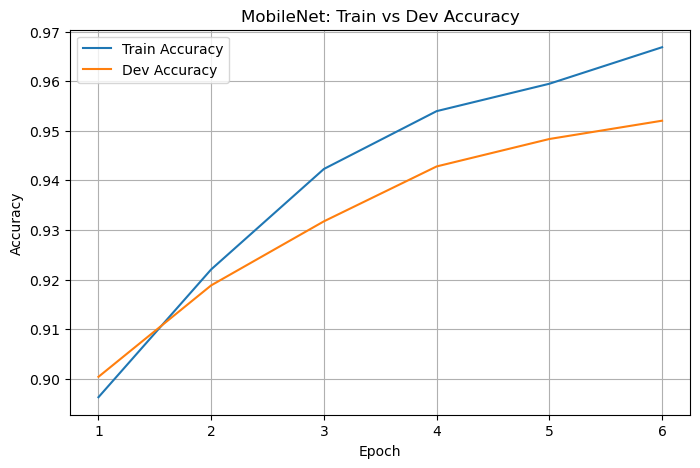

In [59]:
# === Accuracy Plot ===
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_acc_history, label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), dev_acc_history, label='Dev Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNet: Train vs Dev Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Final Accuracy of Mobilenet

In [60]:
# Defining Accuracy 
def test_accuracy_mobilenet(mobilenet, test_loader):
    mobilenet.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, laAsbels = images.to(device), labels.to(device)
            outputs = mobilenet(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f" Final Test Accuracy (MobileNet): {acc * 100:.2f}%")

test_accuracy_mobilenet(mobilenet, test_loader)

 Final Test Accuracy (MobileNet): 95.24%


###  Task 2.3 – Comparative Evaluation

**MobileNet (Task 2.2)** outperformed the custom CNN model overall in terms of both learning speed and final accuracy. It achieved higher dev and test accuracy within fewer epochs due to transfer learning from pretrained ImageNet features and freezing most base layers, which reduced overfitting.

**The custom CNN (Task 2.1)** showed steady learning and decent generalization. However, it required more epochs to converge and still didn’t reach the same accuracy as MobileNet. It also demonstrated slight overfitting when the number of epochs increased beyond 5.

---

####  Confusion Matrix Analysis

From the confusion matrix of the best-performing model (MobileNet), the most common misclassification was:

 **True class:** *rock*  
 **Predicted as:** *scissors*  
 **Occurrences:** *5 times*

This may be due to the visual similarity between hand shapes, rotation angles, or occlusions caused by lighting and background noise.

To investigate this further, we displayed 5 misclassified images that showed this error. These images helped identify model limitations, such as misinterpreting fingers partially covered or rotated in confusing angles.

**Conclusion:**  
MobileNet demonstrated faster and better learning due to pre-trained features, while the custom CNN required more tuning. However, both models performed reasonably well. Misclassification patterns show that even strong models may struggle with visual ambiguity, reinforcing the importance of diverse and well-structured training data.


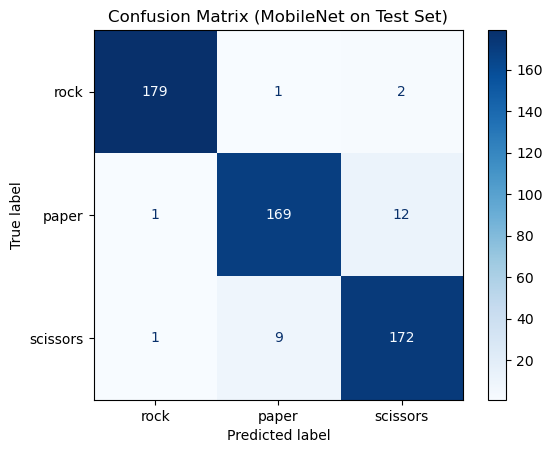

In [ ]:
#Task 2.3(b)
def display_confusion_matrix(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Display Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['rock', 'paper', 'scissors'])
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (MobileNet on Test Set)")
    plt.show()
    return cm, all_preds, all_labels

conf_matrix, all_preds, all_labels = display_confusion_matrix(mobilenet, test_loader) 

### Common Classification Error and Misclassified Image Examples

Most common error: True '1' predicted as '2'


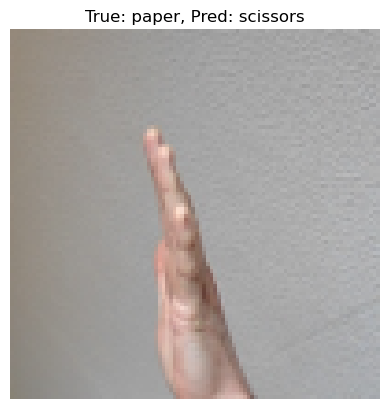

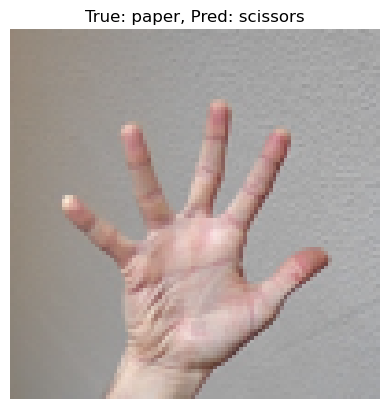

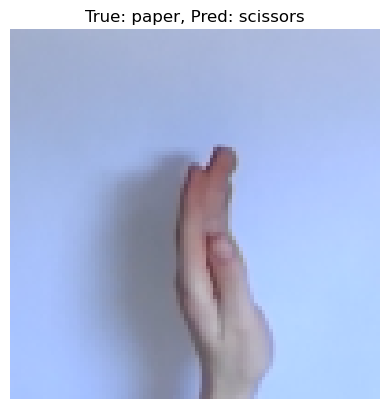

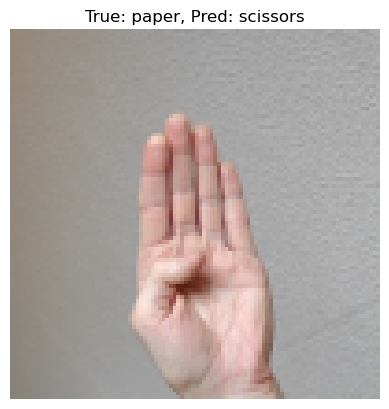

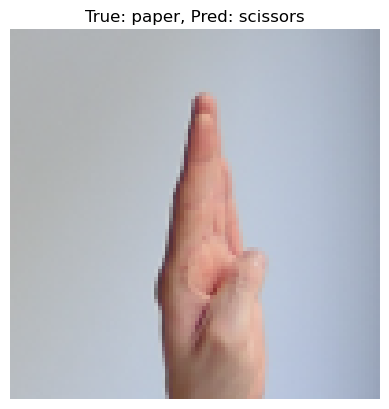

In [ ]:
#Task 2.3(c)
# Identifying most common misclassification
cm_array = np.array(conf_matrix)
np.fill_diagonal(cm_array, 0)
max_mis = np.unravel_index(np.argmax(cm_array), cm_array.shape)
true_label, predicted_label = max_mis

print(f"Most common error: True '{true_label}' predicted as '{predicted_label}'")

# Showing 5 misclassified examples
shown = 0
class_names = ['rock', 'paper', 'scissors']

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = mobilenet(images)
    _, preds = torch.max(outputs, 1)

    for i in range(len(images)):
        if labels[i].item() == true_label and preds[i].item() == predicted_label:
            img = images[i].cpu().permute(1, 2, 0).numpy()
            plt.imshow(img)
            plt.title(f"True: {class_names[true_label]}, Pred: {class_names[predicted_label]}")
            plt.axis('off')
            plt.show()
            shown += 1
            if shown == 5:
                break
    if shown == 5:
        break


### **Task 3.1** Capturing Image for Rock 

In [ ]:
#Task 3.1(Rock)
label = 'rock'
output_dir = os.path.join('webcam_dataset', label)
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")

count = 0
print(" Capturing ROCK images (press 's' to save, 'q' to quit)")

while count < 100:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame.")
        break

    cv2.imshow("Rock - Press 's' to save", frame)
    key = cv2.waitKey(1)

    if key == ord('s'):
        filename = os.path.join(output_dir, f"{label}_{count}.jpg")
        cv2.imwrite(filename, frame)  # Save in color
        print(f" Saved {filename}")
        count += 1
    elif key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


📸 Capturing ROCK images (press 's' to save, 'q' to quit)
✅ Saved webcam_dataset\rock\rock_0.jpg
✅ Saved webcam_dataset\rock\rock_1.jpg
✅ Saved webcam_dataset\rock\rock_2.jpg
✅ Saved webcam_dataset\rock\rock_3.jpg
✅ Saved webcam_dataset\rock\rock_4.jpg
✅ Saved webcam_dataset\rock\rock_5.jpg
✅ Saved webcam_dataset\rock\rock_6.jpg
✅ Saved webcam_dataset\rock\rock_7.jpg
✅ Saved webcam_dataset\rock\rock_8.jpg
✅ Saved webcam_dataset\rock\rock_9.jpg
✅ Saved webcam_dataset\rock\rock_10.jpg
✅ Saved webcam_dataset\rock\rock_11.jpg
✅ Saved webcam_dataset\rock\rock_12.jpg
✅ Saved webcam_dataset\rock\rock_13.jpg
✅ Saved webcam_dataset\rock\rock_14.jpg
✅ Saved webcam_dataset\rock\rock_15.jpg
✅ Saved webcam_dataset\rock\rock_16.jpg
✅ Saved webcam_dataset\rock\rock_17.jpg
✅ Saved webcam_dataset\rock\rock_18.jpg
✅ Saved webcam_dataset\rock\rock_19.jpg
✅ Saved webcam_dataset\rock\rock_20.jpg
✅ Saved webcam_dataset\rock\rock_21.jpg
✅ Saved webcam_dataset\rock\rock_22.jpg
✅ Saved webcam_dataset\rock\rock_

### Capturing Image for Paper

In [ ]:
#Task 3.1(Paper Images)
label = 'paper'
output_dir = os.path.join('webcam_dataset', label)
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")

count = 0
print(" Capturing PAPER images (press 's' to save, 'q' to quit)")

while count < 100:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame.")
        break

    cv2.imshow("Paper - Press 's' to save", frame)
    key = cv2.waitKey(1)

    if key == ord('s'):
        filename = os.path.join(output_dir, f"{label}_{count}.jpg")
        cv2.imwrite(filename, frame)
        print(f" Saved {filename}")
        count += 1
    elif key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


📸 Capturing PAPER images (press 's' to save, 'q' to quit)
✅ Saved webcam_dataset\paper\paper_0.jpg
✅ Saved webcam_dataset\paper\paper_1.jpg
✅ Saved webcam_dataset\paper\paper_2.jpg
✅ Saved webcam_dataset\paper\paper_3.jpg
✅ Saved webcam_dataset\paper\paper_4.jpg
✅ Saved webcam_dataset\paper\paper_5.jpg
✅ Saved webcam_dataset\paper\paper_6.jpg
✅ Saved webcam_dataset\paper\paper_7.jpg
✅ Saved webcam_dataset\paper\paper_8.jpg
✅ Saved webcam_dataset\paper\paper_9.jpg
✅ Saved webcam_dataset\paper\paper_10.jpg
✅ Saved webcam_dataset\paper\paper_11.jpg
✅ Saved webcam_dataset\paper\paper_12.jpg
✅ Saved webcam_dataset\paper\paper_13.jpg
✅ Saved webcam_dataset\paper\paper_14.jpg
✅ Saved webcam_dataset\paper\paper_15.jpg
✅ Saved webcam_dataset\paper\paper_16.jpg
✅ Saved webcam_dataset\paper\paper_17.jpg
✅ Saved webcam_dataset\paper\paper_18.jpg
✅ Saved webcam_dataset\paper\paper_19.jpg
✅ Saved webcam_dataset\paper\paper_20.jpg
✅ Saved webcam_dataset\paper\paper_21.jpg
✅ Saved webcam_dataset\paper

### Capturing Image for Scissors

In [ ]:
#Task 3.1(Scissors)
label = 'scissors'
output_dir = os.path.join('webcam_dataset', label)
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")

count = 0
print(" Capturing SCISSORS images (press 's' to save, 'q' to quit)")

while count < 100:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame.")
        break

    cv2.imshow("Scissors - Press 's' to save", frame)
    key = cv2.waitKey(1)

    if key == ord('s'):
        filename = os.path.join(output_dir, f"{label}_{count}.jpg")
        cv2.imwrite(filename, frame)
        print(f" Saved {filename}")
        count += 1
    elif key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


📸 Capturing SCISSORS images (press 's' to save, 'q' to quit)
✅ Saved webcam_dataset\scissors\scissors_0.jpg
✅ Saved webcam_dataset\scissors\scissors_1.jpg
✅ Saved webcam_dataset\scissors\scissors_2.jpg
✅ Saved webcam_dataset\scissors\scissors_3.jpg
✅ Saved webcam_dataset\scissors\scissors_4.jpg
✅ Saved webcam_dataset\scissors\scissors_5.jpg
✅ Saved webcam_dataset\scissors\scissors_6.jpg
✅ Saved webcam_dataset\scissors\scissors_7.jpg
✅ Saved webcam_dataset\scissors\scissors_8.jpg
✅ Saved webcam_dataset\scissors\scissors_9.jpg
✅ Saved webcam_dataset\scissors\scissors_10.jpg
✅ Saved webcam_dataset\scissors\scissors_11.jpg
✅ Saved webcam_dataset\scissors\scissors_12.jpg
✅ Saved webcam_dataset\scissors\scissors_13.jpg
✅ Saved webcam_dataset\scissors\scissors_14.jpg
✅ Saved webcam_dataset\scissors\scissors_15.jpg
✅ Saved webcam_dataset\scissors\scissors_16.jpg
✅ Saved webcam_dataset\scissors\scissors_17.jpg
✅ Saved webcam_dataset\scissors\scissors_18.jpg
✅ Saved webcam_dataset\scissors\sciss

### Dataset Partitioning

In [ ]:
def create_split_csvs(data_dir='webcam_dataset', output_dir='webcam_dataset/splits'):
    os.makedirs(output_dir, exist_ok=True)

    classes = ['rock', 'paper', 'scissors']
    partitions = {'train': 50, 'devtest': 25, 'test': 25}

    # Create a dictionary to hold rows for each split
    split_data = {key: [] for key in partitions}

    for cls in classes:
        class_dir = os.path.join(data_dir, cls)
        image_files = [f for f in os.listdir(class_dir) if f.endswith('.jpg') or f.endswith('.png')]

        if len(image_files) < 100:
            raise ValueError(f" Not enough images in '{cls}': found {len(image_files)}, need at least 100.")

        random.shuffle(image_files)

        idx = 0
        for split_name, count in partitions.items():
            selected = image_files[idx:idx + count]
            for img in selected:
                split_data[split_name].append({'path': f'{cls}/{img}', 'label': cls})
            idx += count

    # Save separate CSV files
    for split_name, rows in split_data.items():
        csv_path = os.path.join(output_dir, f"{split_name}.csv")
        df = pd.DataFrame(rows)
        df.to_csv(csv_path, index=False)
        print(f" Created {csv_path} with {len(rows)} rows.")

# Run it
create_split_csvs()


✅ Created webcam_dataset/splits\train.csv with 150 rows.
✅ Created webcam_dataset/splits\devtest.csv with 75 rows.
✅ Created webcam_dataset/splits\test.csv with 75 rows.


### Displaying sample image from each partition 
- Train 
- DevTest 
- Test


 Showing samples from: webcam_dataset/splits/train.csv


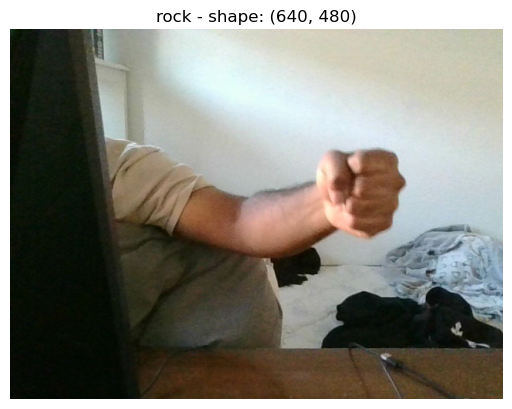

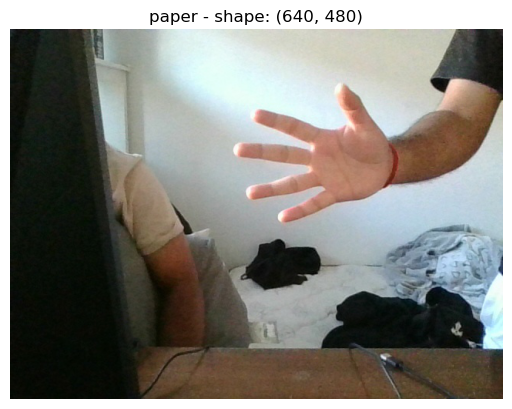

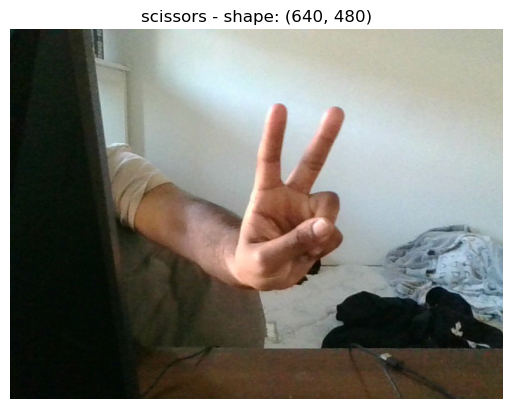


 Showing samples from: webcam_dataset/splits/devtest.csv


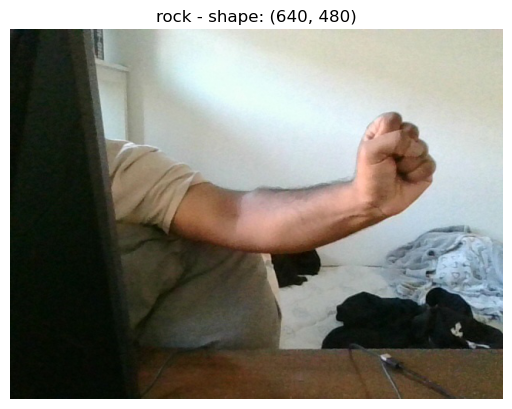

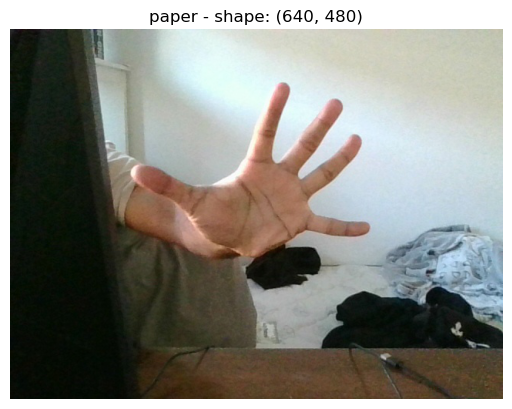

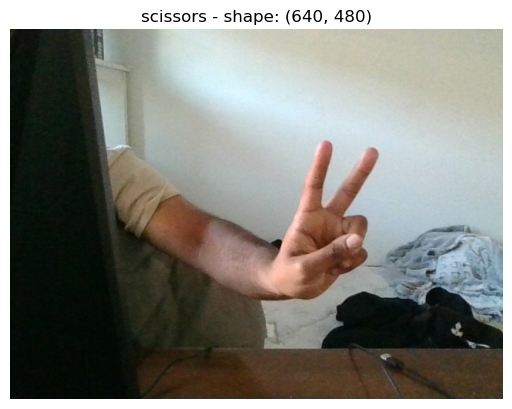


 Showing samples from: webcam_dataset/splits/test.csv


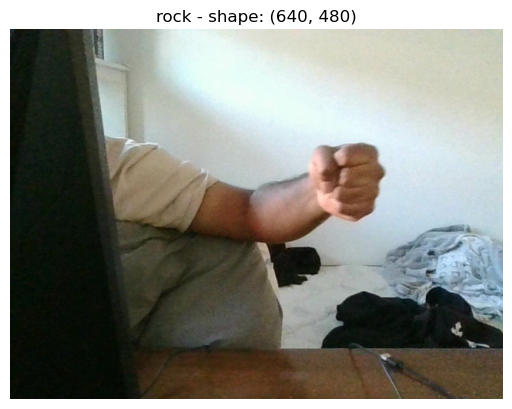

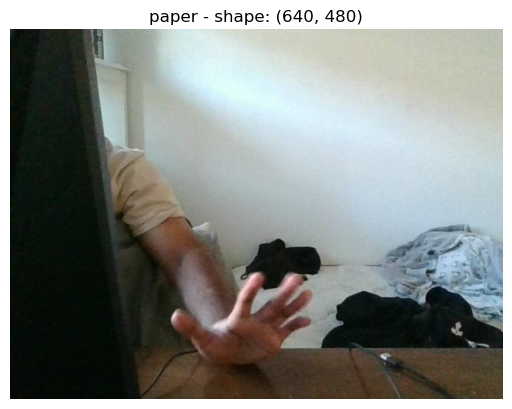

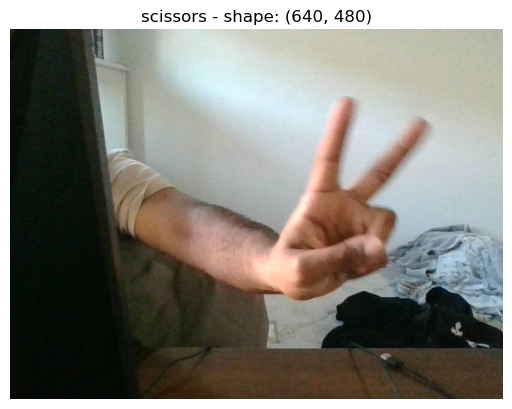

In [66]:
def show_sample_images(csv_path, base_dir='webcam_dataset'):
    df = pd.read_csv(csv_path)
    shown = set()

    print(f"\n Showing samples from: {csv_path}")
    for _, row in df.iterrows():
        label = row['label']
        if label not in shown:
            img_path = os.path.join(base_dir, row['path'])
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(f"{label} - shape: {img.size}")
            plt.axis('off')
            plt.show()
            shown.add(label)
        if len(shown) == 3:
            break

# Show one per class from each split
show_sample_images('webcam_dataset/splits/train.csv')
show_sample_images('webcam_dataset/splits/devtest.csv')
show_sample_images('webcam_dataset/splits/test.csv')


###  **Task 3.1** – Image Capture and Dataset Partitioning Explanation

#### 1. Image Capture and Storage
- I used **OpenCV** to capture webcam images for each of the three classes: `rock`, `paper`, and `scissors`.
- Separate folders were created inside the `webcam_dataset` directory:
  - `webcam_dataset/rock`
  - `webcam_dataset/paper`
  - `webcam_dataset/scissors`
- Each image was saved using a **consistent naming format**, such as:
  - `rock_0.jpg`, `rock_1.jpg`, ..., `rock_99.jpg`
  - `paper_0.jpg` to `paper_99.jpg`
  - `scissors_0.jpg` to `scissors_99.jpg`

#### 2. Dataset Partitioning
- For each class, the images were **randomly partitioned** into three sets:
  - **Training set**: 50 images
  - **Validation set (Devtest)**: 25 images
  - **Test set**: 25 images
- The results were saved into three CSV files:
  - `webcam_dataset/splits/train.csv`
  - `webcam_dataset/splits/devtest.csv`
  - `webcam_dataset/splits/test.csv`
- Each CSV contains:
  - `path`: the relative path to the image (e.g., `rock/rock_12.jpg`)
  - `label`: the class label (`rock`, `paper`, or `scissors`)

#### 3. Comparison to Original Dataset
- Compared to the original dataset, my **webcam images introduce more real-world variability**, including:
  - Different lighting conditions
  - Varied and cluttered backgrounds
  - Changes in hand position and camera angle
- These factors **increase the difficulty** of classification and better simulate real-world deployment scenarios.


### **Task 3.2** Fine Tuning and Testing
- Setting random seeds for reproducibility

In [67]:
random.seed(42)
torch.manual_seed(42)

### Dataset and Dataloaders

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=20, translate=(0.15, 0.15), shear=10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

transform_eval = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

class WebcamDataset(Dataset):
    def __init__(self, csv_path, root_dir, transform):
        self.data = pd.read_csv(csv_path)
        self.root = root_dir
        self.transform = transform
        self.classes = ['rock', 'paper', 'scissors']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        label = self.classes.index(row['label'])
        img_path = os.path.join(self.root, row['path'])
        try:
            img = Image.open(img_path).convert("RGB")
        except:
            return self.__getitem__((idx + 1) % len(self.data))
        return self.transform(img), label

webcam_root = "webcam_dataset"
train_dataset = WebcamDataset("webcam_dataset/splits/train.csv", webcam_root, transform_train)
dev_dataset = WebcamDataset("webcam_dataset/splits/devtest.csv", webcam_root, transform_eval)
test_dataset = WebcamDataset("webcam_dataset/splits/test.csv", webcam_root, transform_eval)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

### Setting up the Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# Unfreezing  only the last few feature layers for tuning
for param in list(model.features.parameters())[:-10]:
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, 3)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)

### Integrating early stopping into Training

In [ ]:
def compute_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total if total > 0 else 0.0

num_epochs = 12
best_dev_acc = 0
patience = 3
no_improve = 0
train_accs, dev_accs = [], []

for epoch in range(num_epochs):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    train_acc = compute_accuracy(model, train_loader)
    dev_acc = compute_accuracy(model, dev_loader)
    train_accs.append(train_acc)
    dev_accs.append(dev_acc)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.2f}, Dev Acc = {dev_acc:.2f}")

    if dev_acc > best_dev_acc:
        best_dev_acc = dev_acc
        no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(" Early stopping triggered.")
            break

Epoch 1: Train Acc = 0.69, Dev Acc = 0.79
Epoch 2: Train Acc = 0.82, Dev Acc = 0.87
Epoch 3: Train Acc = 0.82, Dev Acc = 0.85
Epoch 4: Train Acc = 0.89, Dev Acc = 0.81
Epoch 5: Train Acc = 0.86, Dev Acc = 0.88
Epoch 6: Train Acc = 0.93, Dev Acc = 0.89
Epoch 7: Train Acc = 0.94, Dev Acc = 0.87
Epoch 8: Train Acc = 0.92, Dev Acc = 0.91
Epoch 9: Train Acc = 0.91, Dev Acc = 0.92
Epoch 10: Train Acc = 0.93, Dev Acc = 0.93
Epoch 11: Train Acc = 0.95, Dev Acc = 0.92
Epoch 12: Train Acc = 0.91, Dev Acc = 0.93


### Loading the best model

In [71]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

### Plotting Training and Dev Accuracy Curves Across Epochs

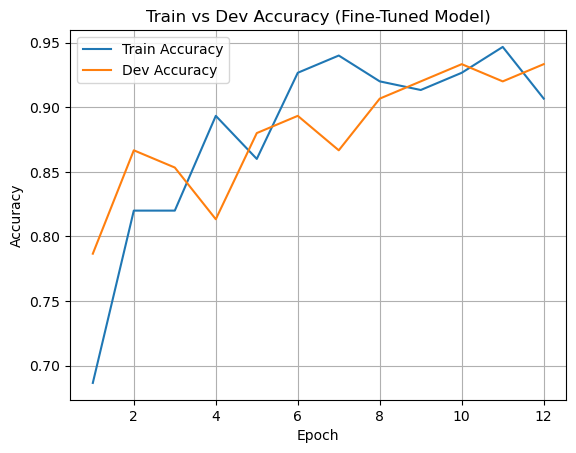

In [72]:
plt.plot(range(1, len(train_accs)+1), train_accs, label="Train Accuracy")
plt.plot(range(1, len(dev_accs)+1), dev_accs, label="Dev Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Dev Accuracy (Fine-Tuned Model)")
plt.legend()
plt.grid(True)
plt.show()


### Final Test Accuracy 

In [74]:
test_acc = compute_accuracy(model, test_loader)
print(f"\n Final Test Accuracy: {test_acc:.2f}")


 Final Test Accuracy: 0.80


 ### Loading Pretrained MobileNetV2 (Base Model for **Task 3.2** Evaluation)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained MobileNet (same as in Task 2)
base_model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
for param in base_model.features.parameters():
    param.requires_grad = False

base_model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(base_model.last_channel, 3)
)

base_model = base_model.to(device)

### Loading Webcam Test Set for Evaluation

In [27]:
test_dataset_new = WebcamDataset("webcam_dataset/splits/test.csv", webcam_root, transform_eval)
test_loader_new = DataLoader(test_dataset_new, batch_size=16)

### Evaluating Base Model on New Test Set (Before Fine-Tuning)

In [76]:
acc_before = compute_accuracy(base_model, test_loader_new)
print(f" Accuracy before fine-tuning (on new test set): {acc_before:.2f}")

 Accuracy before fine-tuning (on new test set): 0.39


###  Evaluate Fine-Tuned Model on New Test Set

In [77]:
acc_after = compute_accuracy(model, test_loader_new)
print(f" Accuracy after fine-tuning (on new test set): {acc_after:.2f}")

 Accuracy after fine-tuning (on new test set): 0.80


###  Evaluating Fine-Tuned Model on Original Test Set (**Task 1**)

In [78]:
original_dir = r"C:\Users\rekit\OneDrive\Desktop\Semester 4\Artificial Intelligence For Text And Vision (3420)\assignment-2-RakinRayan"
task1_test_dataset = WebcamDataset(os.path.join(original_dir, "test.csv"), original_dir, transform_eval)
task1_test_loader = DataLoader(task1_test_dataset, batch_size=16)

acc_on_original = compute_accuracy(model, task1_test_loader)
print(f" Accuracy of fine-tuned model on original test set: {acc_on_original:.2f}")


 Accuracy of fine-tuned model on original test set: 0.64


## **Task 3.2** – Final Summary and Reflection

We evaluated the best system from Task 2 (MobileNet pretrained on ImageNet) under three different conditions:

-  **Before fine-tuning** on new webcam data, the model achieved:  
   **39% accuracy** on the new test set.

-  **After fine-tuning** the model using 50 webcam images per class:  
   **80% accuracy** on the new test set (Webcam images).  
   This shows strong domain adaptation to the new data.

-  When testing the **fine-tuned model** on the **original test set** from Task 1:  
   Accuracy was **64%**.  
   This highlights a **loss in generalization** to the original domain.



###  Conclusion

Fine-tuning improved the model’s performance on the new dataset but reduced its ability to generalize. This happened because the model adapted to specific characteristics of the webcam data (e.g., lighting, background, hand position, camera angle). 

In real-world scenarios, it's important to balance **adaptation** and **generalization**—especially when the deployment environment differs from the training data.
